In [2]:
import importlib
import aaro_draft
import pandas as pd
import matplotlib.pyplot as plt
import Conor
from IPython.display import Image, display
from joblib import Parallel, delayed
import Conor as c

# Reward 1

In [4]:
scalings = [0.01, 0.05, 0.1, 0.5, 1, 5, 10, 50, 100, 500]

configs = [
    c.ExpConfig(
        starting_state=4.0,
        action_lo=-5.0,
        action_hi=5.0,
        initial_q=100.0,
        rho=10.0,
        reward_step_fn=c.reward_quadratic_asymmetric,
        label=f"scaling={s}",
        scaling=s,
        alpha=0.5,
        nEps=2000,
        n_seeds=10,
    )
    for s in scalings
]

results = c.run_experiment(configs, n_jobs=-1)


--- Running: scaling=0.01 ---
    Done. Final mean VPI: -37.860

--- Running: scaling=0.05 ---
    Done. Final mean VPI: -37.119

--- Running: scaling=0.1 ---
    Done. Final mean VPI: -34.791

--- Running: scaling=0.5 ---
    Done. Final mean VPI: -30.060

--- Running: scaling=1 ---
    Done. Final mean VPI: -20.907

--- Running: scaling=5 ---
    Done. Final mean VPI: -3.620

--- Running: scaling=10 ---
    Done. Final mean VPI: -3.848

--- Running: scaling=50 ---
    Done. Final mean VPI: -59.803

--- Running: scaling=100 ---
    Done. Final mean VPI: -100.696

--- Running: scaling=500 ---
    Done. Final mean VPI: -150.067


In [6]:
import numpy as np
import pandas as pd

summary = []
for s in scalings:
    label = f"scaling={s}"
    vpi = results[label]["vpi"]
    arms = results[label]["arms"]

    summary.append({
        "scaling": s,
        "final_cum_reward": np.sum(vpi),
        "late_mean_reward": np.mean(vpi[-100:]),
        "final_arms": arms[-1],
        "mean_arms_last100": np.mean(arms[-100:])
    })

summary_df = pd.DataFrame(summary)
summary_df

,scaling,final_cum_reward,late_mean_reward,final_arms,mean_arms_last100
0,0.01,-75230.249198,-37.860391,217.3,217.300
1,0.05,-73985.457800,-37.118576,218.2,218.095
2,0.10,-69042.618502,-34.791487,217.6,217.405
3,0.50,-60347.781717,-30.059959,216.7,216.700
4,1.00,-44234.328938,-20.907437,218.8,218.800
5,5.00,-14290.915012,-3.620484,225.4,223.996
6,10.00,-14165.577227,-3.847504,221.2,217.951
7,50.00,-135682.499890,-59.802531,214.3,213.928
8,100.00,-217859.215035,-100.695568,213.4,211.942
9,500.00,-281189.325493,-150.066500,217.0,217.000


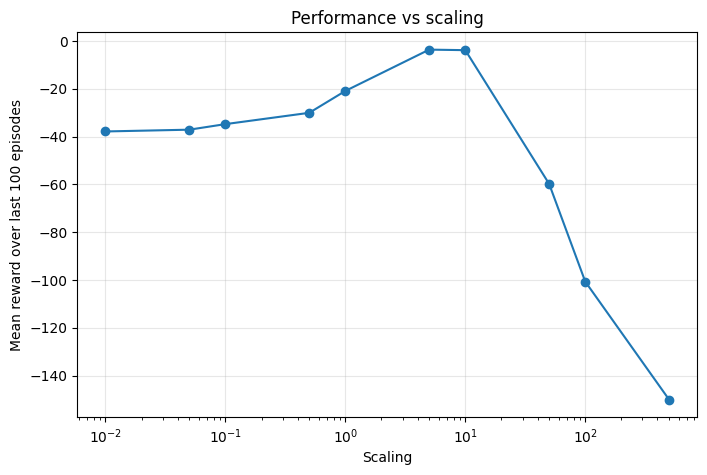

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(summary_df["scaling"], summary_df["late_mean_reward"], marker="o")
plt.xscale("log")
plt.xlabel("Scaling")
plt.ylabel("Mean reward over last 100 episodes")
plt.title("Performance vs scaling")
plt.grid(True, alpha=0.3)
plt.show()

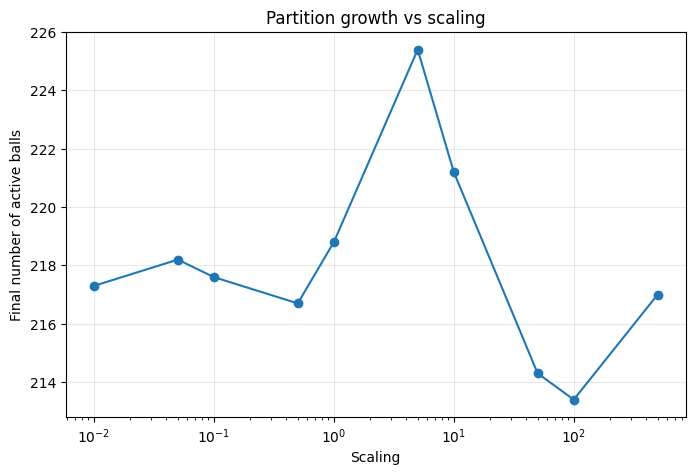

In [8]:
plt.figure(figsize=(8,5))
plt.plot(summary_df["scaling"], summary_df["final_arms"], marker="o")
plt.xscale("log")
plt.xlabel("Scaling")
plt.ylabel("Final number of active balls")
plt.title("Partition growth vs scaling")
plt.grid(True, alpha=0.3)
plt.show()

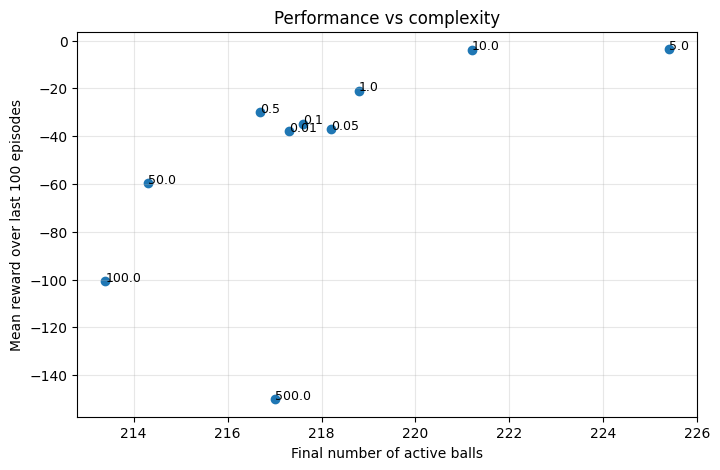

In [9]:
plt.figure(figsize=(8,5))
plt.scatter(summary_df["final_arms"], summary_df["late_mean_reward"])

for _, row in summary_df.iterrows():
    plt.annotate(
        str(row["scaling"]),
        (row["final_arms"], row["late_mean_reward"]),
        fontsize=9
    )

plt.xlabel("Final number of active balls")
plt.ylabel("Mean reward over last 100 episodes")
plt.title("Performance vs complexity")
plt.grid(True, alpha=0.3)
plt.show()